# Project 1 Starter

ECE 232E Summer 2026 - Project 1: Random Graphs and Random Walks  
Posted: Friday, June 26, 2026  
Due: Friday, July 10, 2026 at 11:59 PM PST

This notebook is a lightweight Python scaffold. It gives a few small examples and leaves the main implementation and analysis choices to you.


## Requirements

Recommended environment:

- Python 3.10+ with Jupyter
- Python package: `numpy`
- Python package: `igraph`, installed with `pip install igraph`

You may use additional plotting or data-analysis packages in your own solution.


In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(232)
print(f"igraph version: {ig.__version__}")


igraph version: 1.0.0


# Toy Example

In [2]:
g = ig.Graph.Erdos_Renyi(n=8, p=0.3, directed=False, loops=False)

print(g.summary())
print("edges:", g.get_edgelist())
print("degrees:", g.degree())

IGRAPH U--- 8 7 -- 
edges: [(0, 1), (0, 4), (2, 5), (3, 5), (2, 7), (3, 7), (5, 7)]
degrees: [2, 1, 2, 2, 1, 3, 0, 3]


## Small Graph Examples

Python `igraph` uses 0-based vertex indices. The cells below create tiny graphs only to show the API shape; they are not part of the experiments you need to report.


In [3]:
g_undirected = ig.Graph.Erdos_Renyi(n=8, p=0.3, directed=False, loops=False)
g_directed = ig.Graph.Erdos_Renyi(n=8, p=0.4, directed=True, loops=False)

print(g_undirected.summary())
print("Undirected degrees:", g_undirected.degree())
print(g_directed.summary())
print("Directed out-degrees:", g_directed.degree(mode="out"))


IGRAPH U--- 8 7 -- 
Undirected degrees: [4, 2, 1, 2, 2, 0, 1, 2]
IGRAPH D--- 8 28 -- 
Directed out-degrees: [4, 4, 4, 2, 3, 2, 2, 7]


In [8]:
n = 900
p = 0.006

g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
deg = np.asarray(g.degree())

print("empirical mean:", deg.mean())
print("theory mean:", (n - 1) * p)
print("empirical variance:", deg.var())
print("theory variance:", (n - 1) * p * (1 - p))

empirical mean: 5.366666666666666
theory mean: 5.394
empirical variance: 5.285555555555556
theory variance: 5.361636


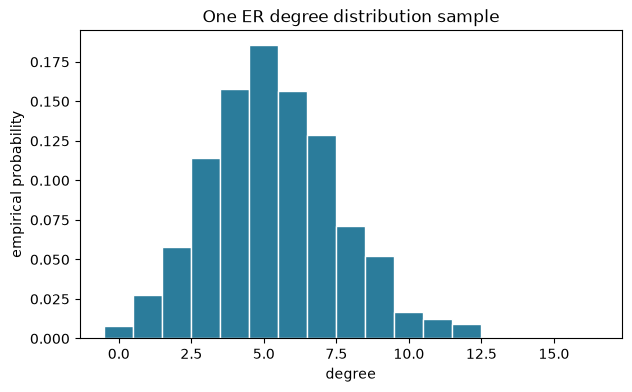

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(deg, bins=np.arange(deg.max() + 2) - 0.5, density=True,
edgecolor="white", color="#2B7C9B")
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One ER degree distribution sample")
plt.show()

In [10]:
# n = 900
# p = 0.06

# g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
# deg = np.asarray(g.degree())

# print("empirical mean:", deg.mean())
# print("theory mean:", (n - 1) * p)
# print("empirical variance:", deg.var())
# print("theory variance:", (n - 1) * p * (1 - p))

In [11]:
# plt.figure(figsize=(7, 4))
# plt.hist(deg, bins=np.arange(deg.max() + 2) - 0.5, density=True,
# edgecolor="white", color="#2B7C9B")
# plt.xlabel("degree")
# plt.ylabel("empirical probability")
# plt.title("One ER degree distribution sample")
# plt.show()

# ER Connectivity and GCC

In [13]:
def er_summary(n, p):
    g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
    comps = g.connected_components()
    sizes = np.asarray(comps.sizes())
    gcc = comps.giant()
    return {
        "connected": g.is_connected(),
        "gcc_fraction": sizes.max() / n,
        "gcc_diameter": gcc.diameter(),
    }

er_summary(900,0.006)

{'connected': False,
 'gcc_fraction': np.float64(0.9966666666666667),
 'gcc_diameter': 8}

In [17]:
ps = [0.001, 0.003, 0.006, 0.01]
trials = 20

for p in ps:
    rows = [er_summary(900, p) for i in range(trials)]
    prob_connected = np.mean([row["connected"] for row in rows])
    avg_gcc_fraction = np.mean([row["gcc_fraction"] for row in rows])
    print(f"p={p:0.3f} P(conn)~{prob_connected:0.2f} avg GCC frac~{avg_gcc_fraction:0.2f}")

p=0.001 P(conn)~0.00 avg GCC frac~0.04
p=0.003 P(conn)~0.00 avg GCC frac~0.92
p=0.006 P(conn)~0.05 avg GCC frac~1.00
p=0.010 P(conn)~0.85 avg GCC frac~1.00


In [18]:
print("GCC emergence guidepost: 1/n =", 1 / 900)
print("connectivity guidepost: log(n)/n =", np.log(900) / 900)

GCC emergence guidepost: 1/n = 0.0011111111111111111
connectivity guidepost: log(n)/n = 0.007558216403693679


# Preferrential Attachement Basis

In [21]:
g_pa = ig.Graph.Barabasi(n=1050, m=1, directed=False)

print(g_pa.summary())
print("connected:", g_pa.is_connected())
print("max degree:", max(g_pa.degree()))
print("mean degree:", np.mean(g_pa.degree()))
print("degree variance:", np.var(g_pa.degree()))


IGRAPH U--- 1050 1049 -- 
connected: True
max degree: 32
mean degree: 1.9980952380952381
degree variance: 4.700948752834467


In [22]:
for m in [1, 2, 4]:
    g_pa = ig.Graph.Barabasi(n=1050, m=m, directed=False)
    assortativity = g_pa.assortativity_degree(directed=False)
    communities = g_pa.community_fastgreedy().as_clustering()
    print(
        f"m={m}",
        "edges:", g_pa.ecount(),
        "max degree:", max(g_pa.degree()),
        "assortativity:", assortativity,
        "modularity:", round(communities.modularity, 3),
    )

# Preferential Attachment Degree Distribution





m=1 edges: 1049 max degree: 35 assortativity: -0.0880118797623779 modularity: 0.933
m=2 edges: 2097 max degree: 44 assortativity: -0.05514500970992524 modularity: 0.52
m=4 edges: 4190 max degree: 114 assortativity: -0.025538060817003945 modularity: 0.324


In [24]:
# When m increases, should the graph become more or less sparse? What might that do to diamater and community structure?

for m in [1, 2, 4]:
    g_pa = ig.Graph.Barabasi(n=1050, m=m, directed=False)
    # Degree Distribution
    deg = np.asarray(g_pa.degree())
    deg_mean = np.mean(deg)
    deg_var = np.var(deg)
    # Community Structure
    assortativity = g_pa.assortativity_degree(directed=False)
    communities = g_pa.community_fastgreedy().as_clustering()
    print(
        f"m={m}",
        "edges:", g_pa.ecount(),
        "max degree:", max(g_pa.degree()),
        "mean degree:", deg_mean,
        "degree variance:", deg_var,
        "assortativity:", assortativity,
        "modularity:", round(communities.modularity, 3),
    )


m=1 edges: 1049 max degree: 31 mean degree: 1.9980952380952381 degree variance: 4.952377324263039 assortativity: -0.07016553225407397 modularity: 0.932
m=2 edges: 2097 max degree: 49 mean degree: 3.994285714285714 degree variance: 16.18282448979592 assortativity: -0.0600056866925735 modularity: 0.527
m=4 edges: 4190 max degree: 101 mean degree: 7.980952380952381 degree variance: 66.16344671201814 assortativity: -0.024667682745415618 modularity: 0.316


rough log-log slope: -1.9707382995546405


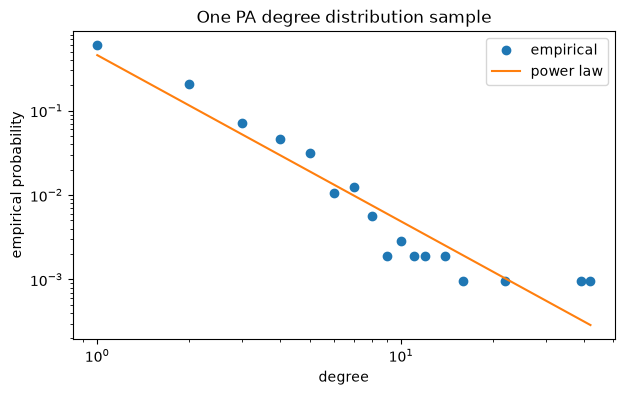

In [28]:
from itertools import count

g_pa = ig.Graph.Barabasi(n=1050, m=1, directed=False)
deg = np.asarray(g_pa.degree())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.loglog(k, prob, "o", label="empirical")
plt.loglog(k, np.exp(intercept) * k**slope, label="power law")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()




In [ ]:
def sample_neighbor_degrees(g, samples =5000, rng=None):
    rng = np.random.default_rng(rng) if rng is None else rng
    seen = []
    for i in range(samples):
        v = int(rng.choice(g.vcount()))
        nbrs = g.neighbors(v)
        if len(nbrs) > 0:
            u = int(rng.choice(nbrs))
            seen.append(g.degree(u))
    return np.asarray(seen)

g_pa = ig.Graph.Barabasi(n=1050, m=1, directed=False)
neighbor_degrees = sample_neighbor_degrees(g_pa, rng=rng)
print("mean node degree:", deg.mean())
print("mean sampled neighbor degree:", np.mean(neighbor_degrees))

# If a node has degree 50, how many opportunities does it have to be selected as someone's neighbor compared with a
# node of degree 2?

# A node with degree 50 has:

# \frac{50}{2} = 25

# So it has 25 times more opportunities to be selected as someone’s neighbor than a node with degree 2.

# In degree-proportional selection, higher-degree nodes are more likely to receive new links because each existing edge gives them another “chance” to be chosen.

mean node degree: 1.9980952380952381
mean sampled neighbor degree: 4.9758


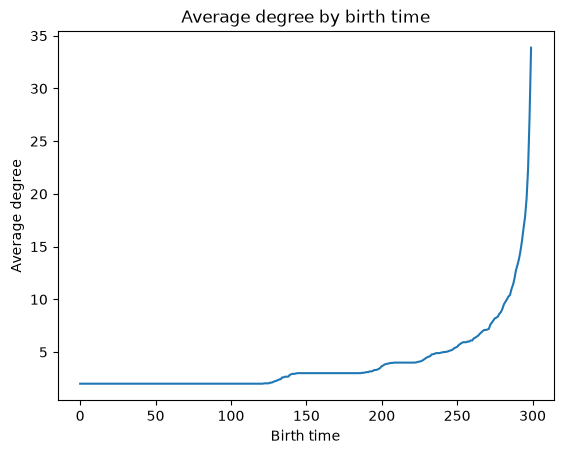

In [31]:
def average_degree_by_birth_time(n=300, m=2, trials=30):
    total = np.zeros(n)
    for i in range(trials):
        g = ig.Graph.Barabasi(n=n, m=m, directed=False)
        deg = np.asarray(g.degree())
        birth_times = np.argsort(deg)
        total += deg[birth_times]
        
    return total / trials

avg_deg = average_degree_by_birth_time()
plt.plot(avg_deg)
plt.xlabel("Birth time")
plt.ylabel("Average degree")
plt.title("Average degree by birth time")
plt.show()
        

In [ ]:
def attachment_probabilities(degrees, ages, alpha=1.0, beta= -1.0):
    degrees = np.asarray(degrees, dtype=float)
    ages = np.asarray(ages, dtype=float)
    weights = (c * degrees**alpha + a) * (d * ages**beta + b)
    return weights / weights.sum()

In [9]:
t = 1050


t - np.arange(t).astype(float)


array([1050, 1049, 1048, ...,    3,    2,    1])

## Transition Matrix

Implement a function that converts a graph into a row-stochastic transition matrix. For row `i`, each entry should be the probability that a walker at node `i` moves to the corresponding next node.

Things to decide and document:

- How to handle directed versus undirected edges.
- How to handle isolated or dangling nodes.
- How to verify that each row sums to 1.


In [3]:
def create_transition_matrix(g):
    """
    Return an n x n transition matrix for graph g.

    Hints:
    - g.vcount() gives the number of vertices.
    - g.get_edgelist() gives edge endpoints.
    - g.is_directed() tells you whether edge direction matters.
    - np.zeros(...) and row normalization may be useful.
    """
    # TODO: implement this function.
    raise NotImplementedError("Implement create_transition_matrix(g).")


## Random Walks

Implement a random-walk simulator. Your implementation should let you run many trials, record the visited nodes, and compute quantities such as distance from the start node at time `t`.

For the random-walk questions, think about:

- Whether the graph is connected, and whether you should restrict to the GCC.
- How many starting nodes or trials are enough for stable averages.
- How to compute shortest-path distances from the starting node.


In [32]:
def walk_by_neighbor(g, start, steps, rng):
    path = [start]
    current = start
    for step in range(steps):
        nbrs = g.neighbors(current)
        if not nbrs:
            current = int(rng.integers(g.vcount()))
        else:
            current = int(rng.choice(nbrs))
        path.append(current)
        
    return np.asarray(path)

path = walk_by_neighbor(g_pa, start=0, steps = 20, rng=rng)
print(path)

[  0  35  45 139 504 139  45 758  45 263  45 758  45 758  45 758  45 139
 504 139 504]


In [ ]:
def random_walk(g, num_steps, start_node=None, transition_matrix=None, rng=None):
    """
    Simulate a random walk and return the path of visited nodes.

    Suggested return value:
    - A NumPy array or list containing the starting node and each subsequent node.
    """
    # TODO: implement this function.
    raise NotImplementedError("Implement random_walk(...).")


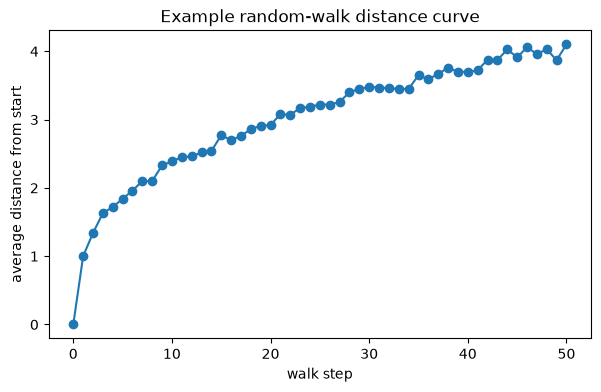

In [39]:
def mean_distance_curve(g, steps=50, trials=200, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    curves = []
    for _ in range(trials):
        start = int(rng.integers(g.vcount()))
        path = walk_by_neighbor(g, start, steps, rng)
        dist_from_start = np.asarray(g.distances(source=start)[0], dtype=float)
        curves.append(dist_from_start[path])
    
    return np.mean(curves, axis = 0)

g_pa = ig.Graph.Barabasi(n=1050, m=1, directed=False)
curve = mean_distance_curve(g_pa, rng=rng)
plt.figure(figsize=(7, 4))
plt.plot(curve, marker="o")
plt.xlabel("walk step")
plt.ylabel("average distance from start")
plt.title("Example random-walk distance curve")
plt.show()

## Visit Probabilities

The PageRank-style parts ask for empirical visit probabilities. After you generate a long path, estimate each node's visit probability from how often it appears in the path.


In [ ]:
def estimate_visit_probabilities(path, n):
    """
    Estimate node visit probabilities from a random-walk path.

    Hints:
    - np.bincount can count visits to integer-labeled nodes.
    - The probabilities should sum to 1.
    """
    # TODO: implement this function.
    raise NotImplementedError("Implement estimate_visit_probabilities(...).")


## Teleportation and Personalized PageRank

Extend your random walk so that, with probability `alpha`, the walker teleports instead of following an outgoing edge. For ordinary PageRank, teleport uniformly over all nodes. For personalized PageRank, use a non-uniform teleportation distribution.

Describe your choice of walk length, burn-in if any, and how you check that results are stable.


In [ ]:
def random_walk_with_teleportation(
    g,
    num_steps,
    start_node=None,
    alpha=0.2,
    teleport_probs=None,
    transition_matrix=None,
    rng=None,
):
    """
    Simulate a random walk with teleportation.

    Suggested behavior:
    - With probability alpha, choose the next node from teleport_probs.
    - Otherwise, follow the graph transition probabilities.
    """
    # TODO: implement this function.
    raise NotImplementedError("Implement random_walk_with_teleportation(...).")


## Analysis Checklist

Use your report to explain both numerical results and modeling choices.

Useful checks while working:

- Degree distributions should match the graph model qualitatively.
- GCC sizes should be averaged over many graph realizations where requested.
- Random-walk distance curves should average over many starts or trials.
- Endpoint or visit distributions should be compared against degree, in-degree, or PageRank as appropriate.
- Plots should have labeled axes, legends when needed, and enough detail to reproduce the result.
